1. import libraries
2. delete unrelated columns
3. convert attrition to binary
4. general look

Columns: 20
Entries: 10127



In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/home/efeherek/Desktop/Data_Analytics_Lab/Project/data/BankChurners.csv')


#deleting clientum id, naive bayes and avg utilization ratio columns as they are not relevant and/or raw data
df = df.iloc[:, 1:-2]

# map the target variable to binary values 
df['Attrition_Flag'] = df['Attrition_Flag'].map({'Existing Customer': 0, 'Attrited Customer': 1})

# general look at the data
# print(df.head())
print(df.info())
sns.set_style("whitegrid")




<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition_Flag            10127 non-null  int64  
 1   Customer_Age              10127 non-null  int64  
 2   Gender                    10127 non-null  str    
 3   Dependent_count           10127 non-null  int64  
 4   Education_Level           10127 non-null  str    
 5   Marital_Status            10127 non-null  str    
 6   Income_Category           10127 non-null  str    
 7   Card_Category             10127 non-null  str    
 8   Months_on_book            10127 non-null  int64  
 9   Total_Relationship_Count  10127 non-null  int64  
 10  Months_Inactive_12_mon    10127 non-null  int64  
 11  Contacts_Count_12_mon     10127 non-null  int64  
 12  Credit_Limit              10127 non-null  float64
 13  Total_Revolving_Bal       10127 non-null  int64  
 14  Avg_Open_To_Buy  

In [56]:
# also check for missing values
print(df.isnull().sum())

Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64


# EDA
Generate plots that show different correlations.

/tmp/ipykernel_4190/1058492876.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attrition_Flag', data=df, palette='viridis')


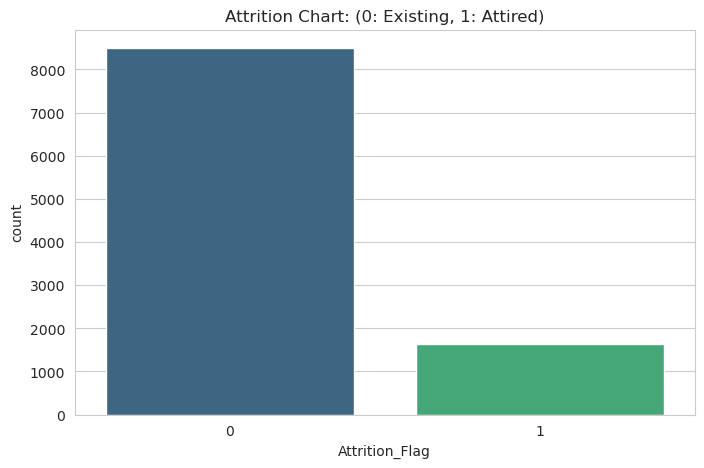

In [57]:

# How many customers are existing vs attiring?
plt.figure(figsize=(8, 5))
sns.countplot(x='Attrition_Flag', data=df, palette='viridis')
plt.title('Attrition Chart: (0: Existing, 1: Attired)')
plt.savefig('Plots/attrition_count.png')

plt.show()

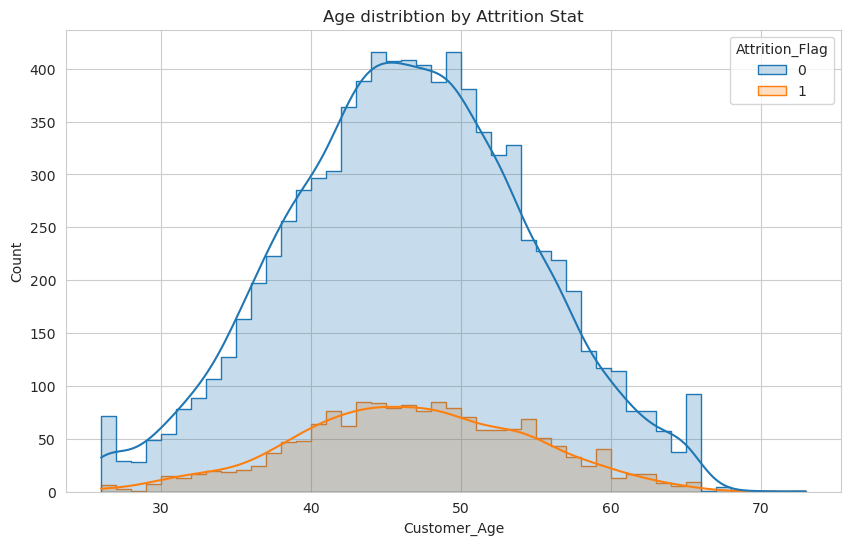

In [58]:
# Age distribution and relevance to attrition
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Customer_Age', hue='Attrition_Flag', kde=True, element="step")
plt.title('Age distribtion by Attrition Stat')
plt.savefig('Plots/attrition_by_age.png')

plt.show()

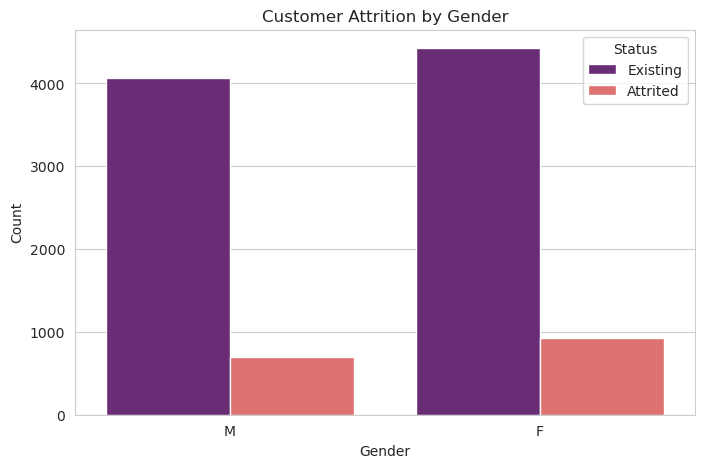

In [59]:
# Analysis of Categorical Variables (Example: Gender)
plt.figure(figsize=(8, 5))
sns.countplot(x='Gender', hue='Attrition_Flag', data=df, palette='magma')
plt.title('Customer Attrition by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Status', labels=['Existing', 'Attrited'])
plt.savefig('Plots/attrition_by_gender.png')

plt.show()

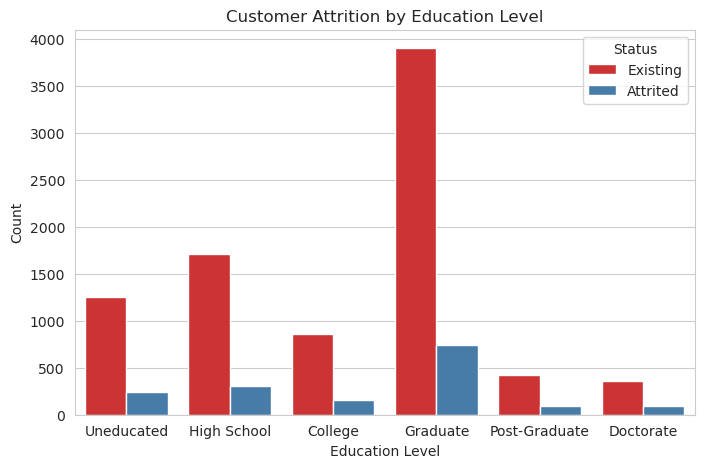

In [60]:
# Education level an attrition
df['Education_Level'] = df['Education_Level'].replace('Unknown', df['Education_Level'].mode()[0])
plt.figure(figsize=(8,5))
sns.countplot(x='Education_Level', hue='Attrition_Flag', data=df, palette='Set1', order=['Uneducated', 'High School', 'College', 'Graduate', 'Post-Graduate', 'Doctorate'])
plt.title('Customer Attrition by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.legend(title='Status', labels=['Existing', 'Attrited'])
plt.savefig('Plots/attrition_by_education.png')
plt.show()

count    10127.000000
mean      8631.953698
std       9088.776650
min       1438.300000
25%       2555.000000
50%       4549.000000
75%      11067.500000
max      34516.000000
Name: Credit_Limit, dtype: float64


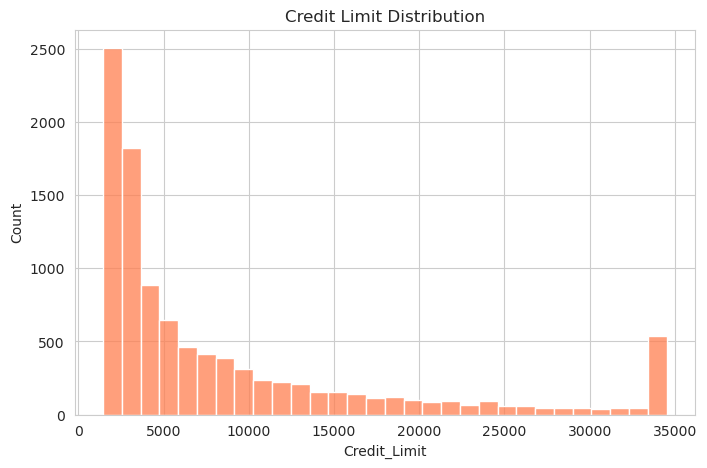

In [61]:
# Credit limit
print(df['Credit_Limit'].describe())
plt.figure(figsize=(8, 5))
sns.histplot(df['Credit_Limit'],bins = 30, kde = False, color='coral')
plt.title('Credit Limit Distribution')
plt.savefig('Plots/credit_limit_distribution.png')
plt.show()

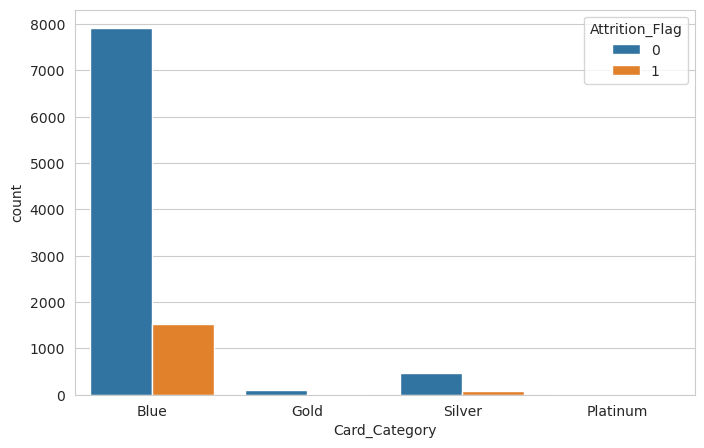

In [62]:
# Card category
plt.figure(figsize=(8,5))
sns.countplot(x='Card_Category', hue= 'Attrition_Flag', data = df)
plt.savefig('Plots/attrition_by_card_category.png')
plt.show()


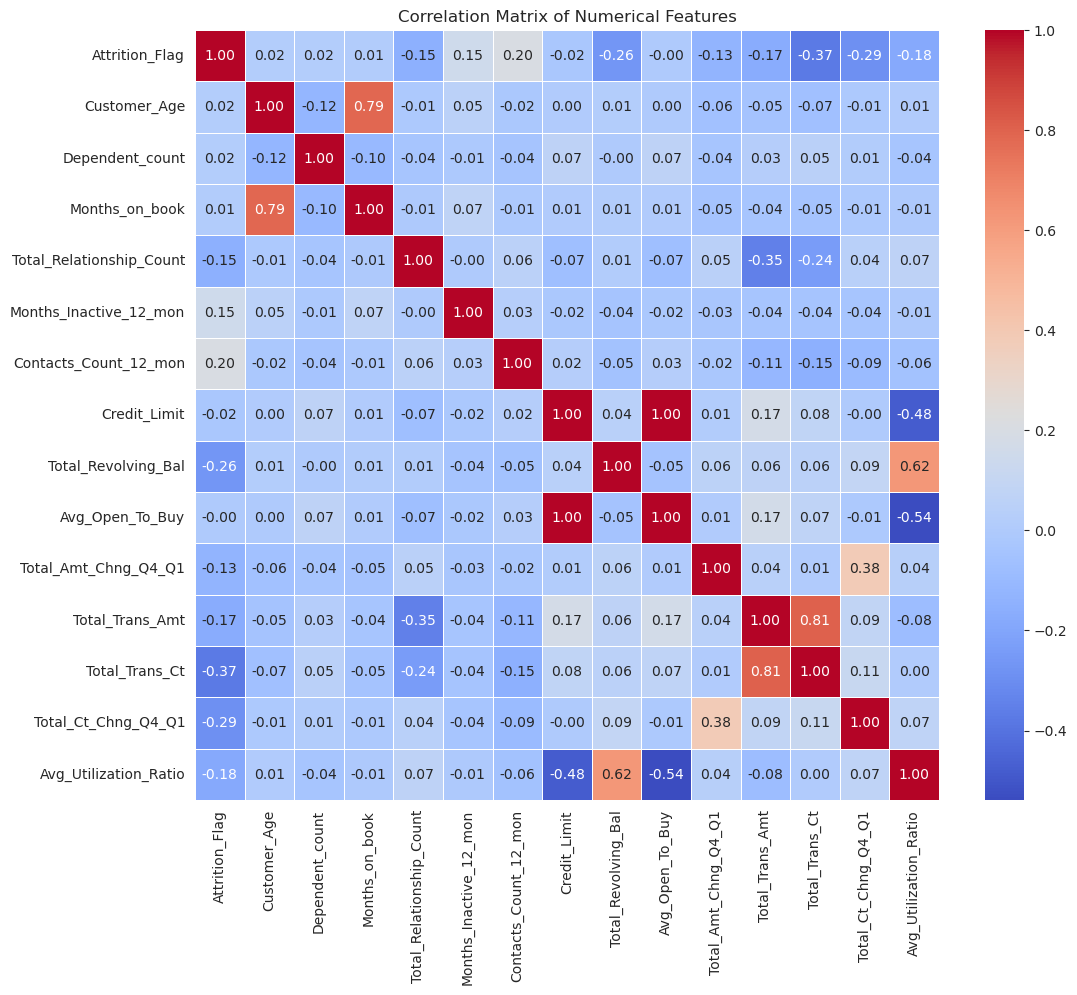

In [63]:
# Correlation Matrix (Relationship between numerical variables)
plt.figure(figsize=(12, 10))
# Selecting only numeric columns
numeric_df = df.select_dtypes(include=[np.number])
# Calculating the correlation
corr_matrix = numeric_df.corr()

# Plotting the heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.savefig('Plots/heatmap.png')

plt.show()

1. Total_Trans_Ct (-0.37): As the number of transactions goes down, the probability of the customer leaving (Attrition) goes up. Basically, if they stop using the card, they are going to quit.  
2. Total_Ct_Chng_Q4_Q1 (-0.29): A drop in transaction count between the first and fourth quarters is a big red flag.  
3. Total_Revolving_Bal (-0.26): Customers with lower revolving balances are more likely to leave. This often suggests they aren't deeply "hooked" into the bank's credit ecosystem.  
4. Contacts_Count_12_mon (0.20): Notice this is positive. This means the more times a customer contacts the bank, the more likely they are to leave. They are probably calling to complain!

Also we see that avg_open_to but and credit_limit have a correlation of 1 this means they are basically the same so we need to remove one of them to avoid multicollinearity.because of the strong 0.79 correlation between customer age and years on book, we do the same


In [64]:
df.drop('Avg_Open_To_Buy', axis=1, inplace=True)
df.drop('Months_on_book',axis=1, inplace=True)

In [65]:
# to check what is left in the data after drop
print(df.columns.tolist())

['Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']


Now that we see in the heatmap what are our biggest candidates, we add couple more visuals to see better

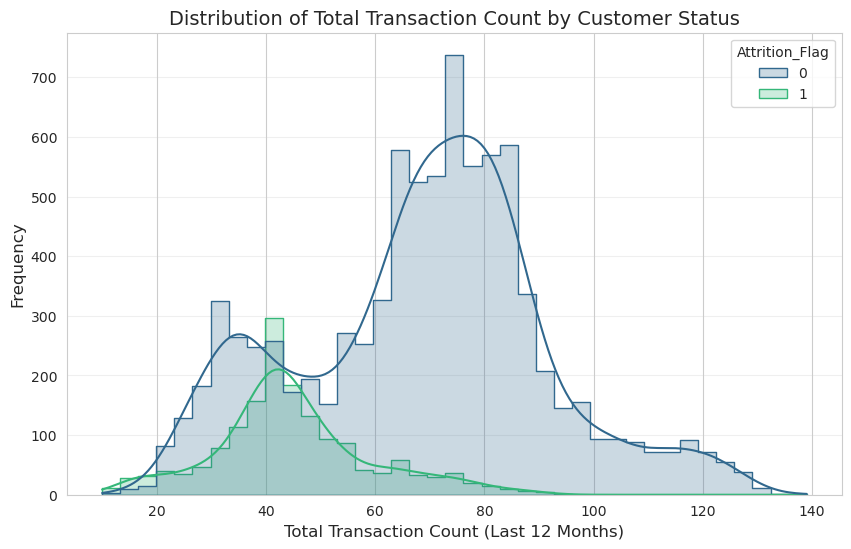

In [66]:
#total transaction count dist. and relevance to attrition because heatmap showed it has strong correlation with attrition flag
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Total_Trans_Ct', hue='Attrition_Flag', kde=True, element="step", palette='viridis')
plt.title('Distribution of Total Transaction Count by Customer Status', fontsize=14)
plt.xlabel('Total Transaction Count (Last 12 Months)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.savefig('Plots/histogram_trans_ct.png')
plt.show()

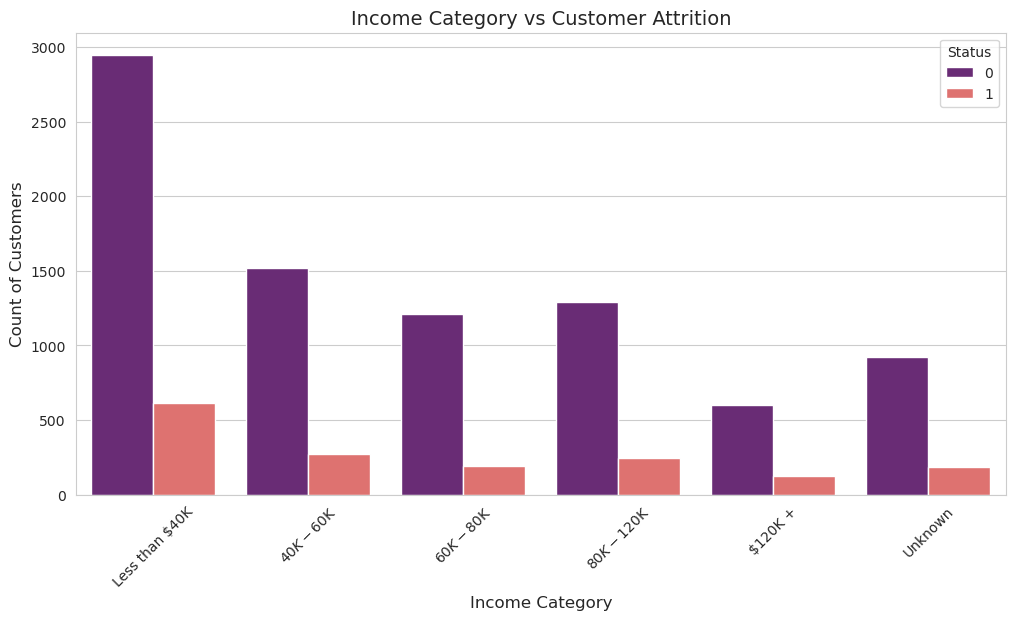

In [67]:
# Bar Chart of Income_Category
# We categorize the income categories in an order that makes it better for visualizaiton.
income_order = ['Less than $40K', '$40K - $60K', '$60K - $80K', '$80K - $120K', '$120K +', 'Unknown']
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Income_Category', hue='Attrition_Flag', order=income_order, palette='magma')
plt.title('Income Category vs Customer Attrition', fontsize=14)
plt.xlabel('Income Category', fontsize=12)
plt.ylabel('Count of Customers', fontsize=12)
plt.savefig('Plots/bar_income_category.png')
plt.xticks(rotation=45)
plt.legend(title='Status')
plt.show()

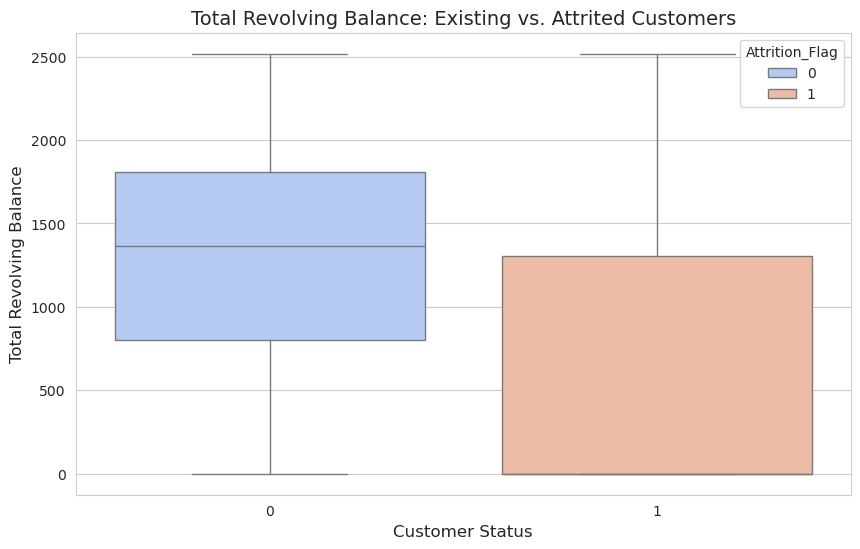

In [68]:
#  Boxplot total revolving balance and relevance to attrition also because of strong correlation in heatmap.
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Attrition_Flag', y='Total_Revolving_Bal', hue='Attrition_Flag', palette='coolwarm', legend=True)
plt.title('Total Revolving Balance: Existing vs. Attrited Customers', fontsize=14)
plt.xlabel('Customer Status', fontsize=12)
plt.ylabel('Total Revolving Balance', fontsize=12)
plt.savefig('Plots/rev_balance_to_attrition.png')
plt.show()

# Pre-processing


In [69]:
df['Gender'] = df['Gender'].map({'M': 1, 'F': 0})
df['Gender'].unique()

X = df.drop(columns=['Attrition_Flag'])
y = df['Attrition_Flag']

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
# We exclude 'Gender' because you already manually encoded it 
if 'Gender' in num_cols: num_cols.remove('Gender')
cat_cols = X.select_dtypes(include=['object']).columns.tolist()



/tmp/ipykernel_4190/1229085135.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns.tolist()


In [81]:
#import some models to test out 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, QuantileTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import cross_val_score


In [71]:
# split the data into training and testing, we use startify to evenly distributet the classes. The dataset in imbalanced.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', QuantileTransformer(output_distribution='normal'), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ], remainder='passthrough') # 'passthrough' keeps the 'Gender' column




# Logistic Regression 

In [72]:
pipeline_log_reg = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight = 'balanced')),
])

#fit
pipeline_log_reg.fit(X_train, y_train)

#Evaluate
y_pred_log = pipeline_log_reg.predict(X_test)
print("--- Logistic Regression Results ---")
print(classification_report(y_test, y_pred_log))



--- Logistic Regression Results ---
              precision    recall  f1-score   support

           0       0.96      0.86      0.91      1701
           1       0.53      0.83      0.65       325

    accuracy                           0.86      2026
   macro avg       0.75      0.85      0.78      2026
weighted avg       0.89      0.86      0.87      2026



# Random Forest Classification

In [73]:
pipeline_random_forest = Pipeline(steps= [
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
])

pipeline_random_forest.fit(X_train, y_train)
y_pred_rf = pipeline_random_forest.predict(X_test)
print("--- Random Forest Results ---")
print(classification_report(y_test, y_pred_rf))



--- Random Forest Results ---
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1701
           1       0.94      0.72      0.81       325

    accuracy                           0.95      2026
   macro avg       0.94      0.85      0.89      2026
weighted avg       0.95      0.95      0.94      2026



In [74]:
pipeline_random_forest_gradient = Pipeline(steps= [
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

pipeline_random_forest_gradient.fit(X_train, y_train)
y_pred_rf_grad = pipeline_random_forest_gradient.predict(X_test)
print("--- Random Forest GradientResults ---")
print(classification_report(y_test, y_pred_rf_grad))

--- Random Forest GradientResults ---
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1701
           1       0.96      0.80      0.88       325

    accuracy                           0.96      2026
   macro avg       0.96      0.90      0.93      2026
weighted avg       0.96      0.96      0.96      2026



# SVM 

In [75]:
pipeline_svm = Pipeline(steps= [
    ('preprocessor', preprocessor),
    ('classifier', SVC(class_weight='balanced'))
])

pipeline_svm.fit(X_train, y_train)
y_pred_svm = pipeline_svm.predict(X_test)
print("--- SVM Results ---")
print(classification_report(y_test, y_pred_svm))


--- SVM Results ---
              precision    recall  f1-score   support

           0       0.97      0.90      0.93      1701
           1       0.62      0.84      0.71       325

    accuracy                           0.89      2026
   macro avg       0.79      0.87      0.82      2026
weighted avg       0.91      0.89      0.90      2026



# Compare model accuracies

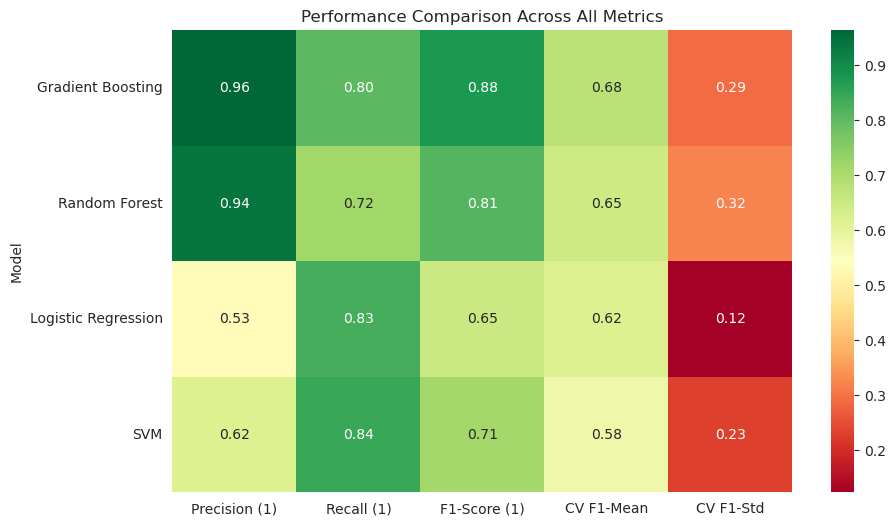

In [83]:
results = []

models = ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'SVM']
pipelines = [pipeline_log_reg, pipeline_random_forest, pipeline_random_forest_gradient, pipeline_svm] 
predictions = [y_pred_log, y_pred_rf, y_pred_rf_grad, y_pred_svm]

for model_name, pipeline, y_pred in zip(models, pipelines,predictions):
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='f1')

    results.append({
        'Model': model_name,
        'Precision (1)': report['1']['precision'],
        'Recall (1)': report['1']['recall'],
        'F1-Score (1)': report['1']['f1-score'],
        'CV F1-Mean': cv_scores.mean(),  #avg perf
        'CV F1-Std': cv_scores.std() # the lower the
    })

comparison_df = pd.DataFrame(results).sort_values(by='CV F1-Mean', ascending=False)
heatmap_data = comparison_df.set_index('Model')
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Performance Comparison Across All Metrics')
plt.savefig('Plots/model_comparison_heatmap.png')
plt.show()

# Confusion Matrix 

<Figure size 800x600 with 0 Axes>

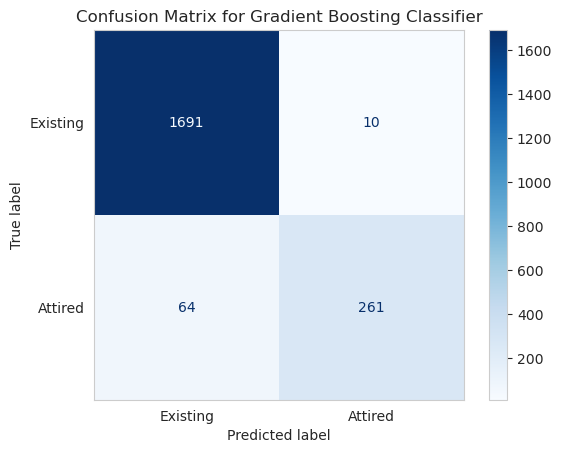

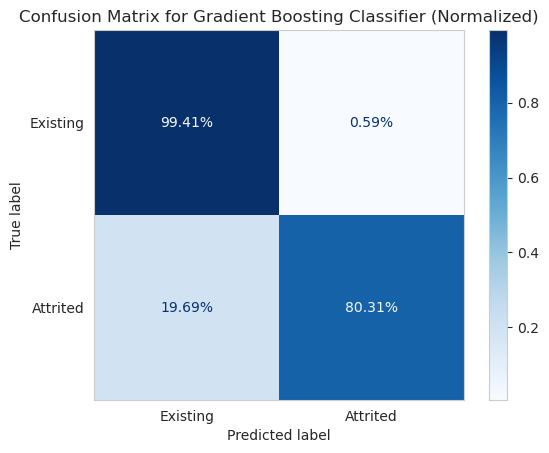

In [77]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf_grad)

plt.figure(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Existing', 'Attired'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix for Gradient Boosting Classifier')
plt.grid(False)
plt.savefig('Plots/confusion_matrix_gradient_boosting.png')
plt.show()

disp_norm = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_rf_grad, 
    display_labels=['Existing', 'Attrited'],
    cmap='Blues',
    normalize='true',
    values_format='.2%',
)
plt.grid(False)
plt.title('Confusion Matrix for Gradient Boosting Classifier (Normalized)')
plt.savefig('Plots/confusion_matrix_gradient_boosting_normalized.png')
plt.show()

# Feature Importance

We will use this to viusalize/see what drove this model to the decision, which feature was more effective.

/tmp/ipykernel_4190/3585548369.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df.head(10), x='Importance', y='Feature', palette='viridis')


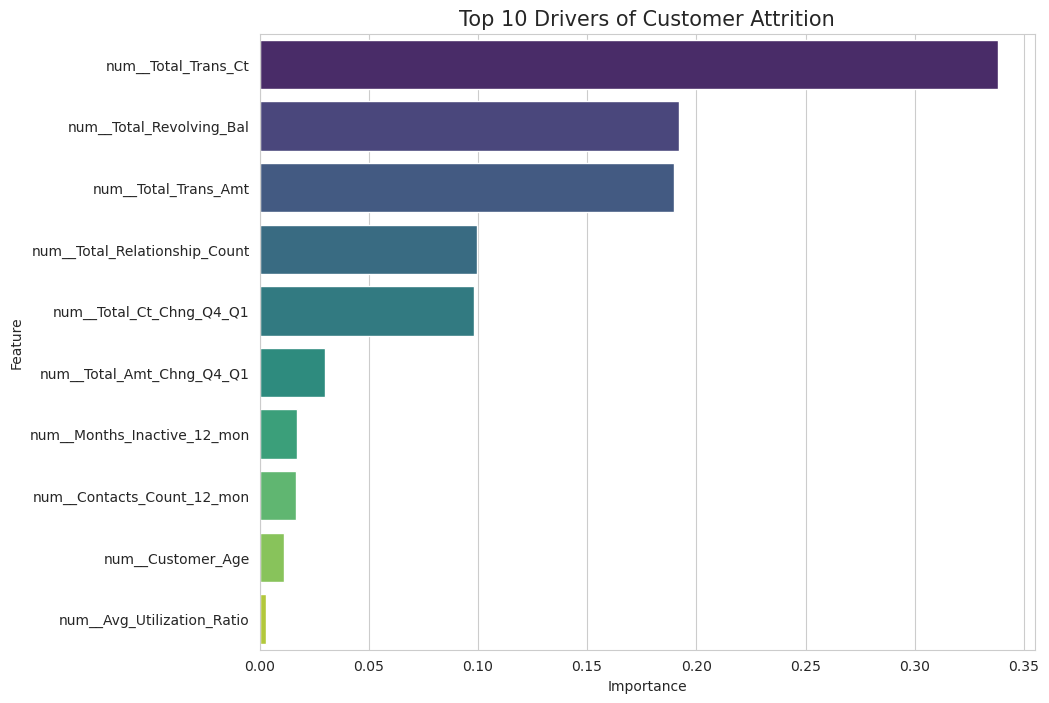

In [78]:
all_feature_names = pipeline_random_forest_gradient.named_steps['preprocessor'].get_feature_names_out()
importances = pipeline_random_forest_gradient.named_steps['classifier'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Drivers of Customer Attrition', fontsize=15)
plt.savefig('Plots/feature_importance.png')
plt.show()

In [79]:
from sklearn.model_selection import GridSearchCV

# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html 
param_grid = {
    'classifier__n_estimators': [100, 150, 200],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__max_depth': [3, 4, 5]
}

# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
grid_search = GridSearchCV(
    estimator=pipeline_random_forest_gradient, 
    param_grid=param_grid, 
    cv=3, 
    scoring='f1', 
    n_jobs=-1 
)

grid_search.fit(X_train, y_train)

# 4. See the results
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation F1-Score: {grid_search.best_score_:.4f}")

# 5. Use the best model to predict on the test set
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

Best Parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 150}
Best Cross-Validation F1-Score: 0.9136


# Gradient Boosted Pipeline with Tuned HyperParameters

Here after applying the tuned parameters our test dataset results actually looked like they improved but when we look at our cross validation mean and std.
It actually shows us that the tuning just found a better fit for the test set. It is not improving real life performance.

--- Random Forest GradientResults ---
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1701
           1       0.96      0.86      0.90       325

    accuracy                           0.97      2026
   macro avg       0.96      0.92      0.94      2026
weighted avg       0.97      0.97      0.97      2026



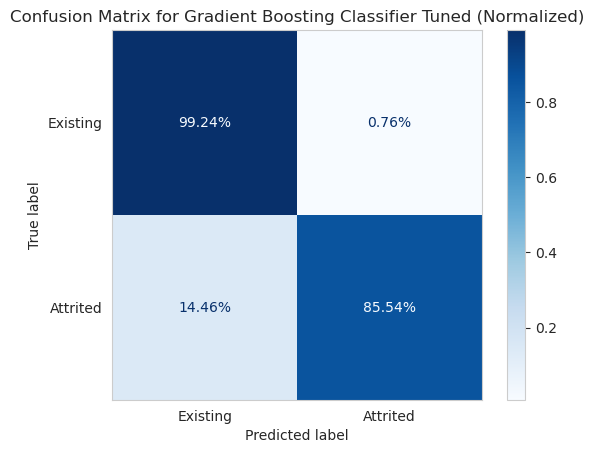

Cross-Validation F1-Mean: 0.8416
Cross-Validation F1-Std: 0.1118


In [ ]:
pipeline_random_forest_gradient_tuned = Pipeline(steps= [
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(learning_rate=0.1, max_depth=5,n_estimators=150))
])

pipeline_random_forest_gradient_tuned.fit(X_train, y_train)
y_pred_rf_grad_tuned = pipeline_random_forest_gradient_tuned.predict(X_test)
print("--- Random Forest GradientResults ---")
print(classification_report(y_test, y_pred_rf_grad_tuned))

disp_norm_tuned = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_rf_grad_tuned, 
    display_labels=['Existing', 'Attrited'],
    cmap='Blues',
    normalize='true',
    values_format='.2%',
)
plt.grid(False)
plt.title('Confusion Matrix for Gradient Boosting Classifier Tuned (Normalized)')
plt.savefig('Plots/confusion_matrix_gradient_boosting_tuned_normalized.png')
plt.show()

report = classification_report(y_test, y_pred_rf_grad_tuned, output_dict=True)
# We increased the folds of CV from 5 to 10. This gave the model more chance to prove itself, thus showing better results
cv_scores = cross_val_score(pipeline_random_forest_gradient_tuned, X, y, cv=10, scoring='f1')
print(f"Cross-Validation F1-Mean: {cv_scores.mean():.4f}")
print(f"Cross-Validation F1-Std: {cv_scores.std():.4f}")

# Save the Model

In [87]:
import joblib

joblib.dump(pipeline_random_forest_gradient_tuned, 'churn_model_pipeline.pkl')
joblib.dump(X.columns.tolist(), 'all_feature_names.pkl')

['all_feature_names.pkl']